In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/custom.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))

# Chapter 8 — Instance-Based Learning
## Lesson 7: KNN Regression and Local Smoothing Bias/Variance

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")

KNN is not limited to predicting categories. In regression, it predicts a continuous value by aggregating the target values of nearby observations. Uniform KNN regression takes the average of the $k$ neighbor targets. Distance-weighted KNN regression gives closer targets more influence. The result is a flexible local smoother: instead of fitting one global equation, the prediction adapts to the observations surrounding each query.

The central question is again neighborhood size. Very small K follows local variation closely and can react to noise. Large K averages broadly and produces a stable smooth curve, but may miss genuine local changes. This is the smoothing version of the bias-variance trade-off. We will make it visible on a synthetic curve, select K for Wine Quality regression by cross-validation, compare weighting rules, inspect residuals, and examine local neighbors behind one prediction.

Wine_Quality.csv contains numeric chemical measurements and an integer quality score. Although quality is discrete in this dataset, treating it as an ordered continuous target is a useful regression demonstration. The output should be interpreted as an estimated score, not as a clinical, commercial, or sensory recommendation.

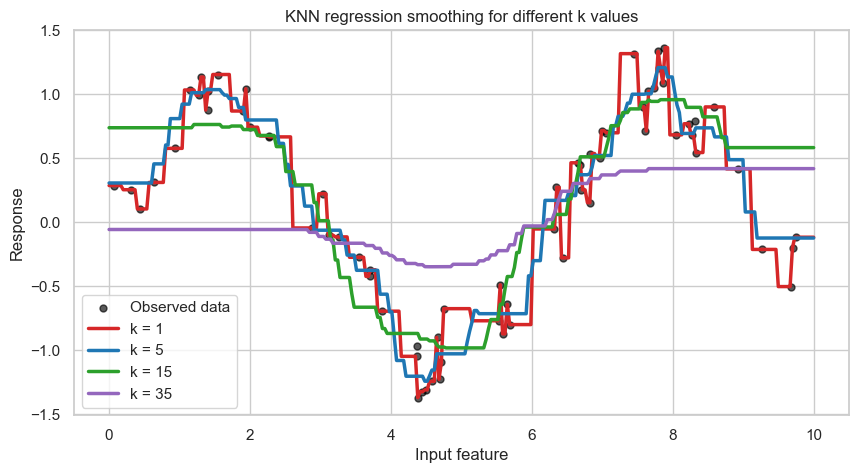

In [3]:
x_train = np.sort(rng.uniform(0, 10, 70))
y_train = np.sin(x_train) + 0.25 * rng.normal(size=x_train.size)
x_grid = np.linspace(0, 10, 300)
k_values = [1, 5, 15, 35]

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(x_train, y_train, color="black", s=25, alpha=0.65, label="Observed data")
for k_value, color in zip(k_values, ["tab:red", "tab:blue", "tab:green", "tab:purple"]):
    model = KNeighborsRegressor(n_neighbors=k_value, weights="uniform").fit(x_train.reshape(-1, 1), y_train)
    ax.plot(x_grid, model.predict(x_grid.reshape(-1, 1)), color=color, linewidth=2.5, label=f"k = {k_value}")
ax.set_xlabel("Input feature")
ax.set_ylabel("Response")
ax.set_title("KNN regression smoothing for different k values")
ax.legend()
plt.show()

### Learning goals

By the end of this lesson, you should be able to:

1. Explain how KNN regression aggregates neighboring target values.
2. Distinguish uniform from distance-weighted KNN regression.
3. Relate small and large K to local smoothing bias and variance.
4. Select K with training-only cross-validation and RMSE.
5. Evaluate continuous predictions with MAE, RMSE, and $R^2$.
6. Use actual-versus-predicted and residual plots to diagnose a regressor.
7. Inspect the neighbors and distances contributing to one continuous prediction.
8. Recognize interpolation, extrapolation, scale, density, and computational limitations.

KNN regression is especially useful when nearby examples are expected to have similar outcomes and a local average is more plausible than one global functional relationship.

In [4]:
wine_path = Path("../../../Datasets/Classification/Wine_Quality.csv")
wine = pd.read_csv(wine_path)
wine_X = wine.drop(columns="quality")
wine_y = wine["quality"]

display(wine.head())
display(wine.dtypes.rename("dtype").to_frame())
display(wine_y.describe().rename("quality").to_frame())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


,dtype
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


,quality
count,4898.000000
mean,5.877909
std,0.885639
min,3.000000
25%,5.000000
50%,6.000000
75%,6.000000
max,9.000000


## 1. The KNN regression rule

For a query $x_*$ and its neighbor set $N_k(x_*)$, uniform KNN regression predicts

$$
\hat{y}(x_*)=\frac{1}{k}\sum_{i\in N_k(x_*)}y_i.
$$

Distance weighting replaces the equal average with weighted evidence:

$$
\hat{y}(x_*)=\frac{\sum_{i\in N_k(x_*)}w_i y_i}{\sum_{i\in N_k(x_*)}w_i},
\qquad
w_i=\frac{1}{d(x_*,x_i)+\epsilon}.
$$

Small K has low smoothing bias because it can follow fine local changes, but it has high variance because one noisy neighbor can change a prediction. Large K has lower variance because many targets are averaged, but it has higher bias because local peaks and valleys are blurred. Distance weighting can recover some local sensitivity, but it also makes very close noisy examples more influential.

,k,mean_rmse,std_rmse
11,23,0.642,0.027
12,25,0.643,0.027
8,17,0.643,0.026
10,21,0.644,0.026
9,19,0.644,0.026
13,27,0.644,0.027
15,31,0.645,0.027
14,29,0.645,0.027
7,15,0.645,0.025
16,33,0.645,0.027


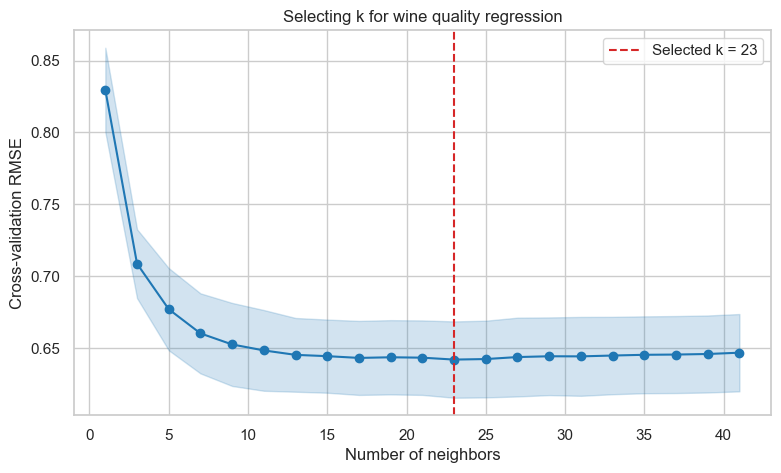

In [5]:
X_train, X_test, y_train, y_test = train_test_split(wine_X, wine_y, test_size=0.25, random_state=RANDOM_STATE)
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
k_grid = list(range(1, 42, 2))
rows = []

for k_value in k_grid:
    model = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=k_value, weights="distance"))
    scores = -cross_val_score(model, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error", error_score="raise")
    rows.append({"k": k_value, "mean_rmse": scores.mean(), "std_rmse": scores.std()})
k_results = pd.DataFrame(rows)
best_k = int(k_results.loc[k_results["mean_rmse"].idxmin(), "k"])
display(k_results.sort_values("mean_rmse").head(10).round(3))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_results["k"], k_results["mean_rmse"], marker="o", color="tab:blue")
ax.fill_between(k_results["k"], k_results["mean_rmse"] - k_results["std_rmse"], k_results["mean_rmse"] + k_results["std_rmse"], alpha=0.2, color="tab:blue")
ax.axvline(best_k, color="tab:red", linestyle="--", label=f"Selected k = {best_k}")
ax.set_xlabel("Number of neighbors")
ax.set_ylabel("Cross-validation RMSE")
ax.set_title("Selecting k for wine quality regression")
ax.legend()
plt.show()

## 2. See smoothing on a controlled curve

The synthetic example uses noisy observations from a sine curve. With K=1, the prediction has a jagged shape that follows individual points. With moderate K, the curve tracks the underlying pattern while suppressing noise. With large K, the estimator becomes very smooth and can flatten the oscillation.

This visual intuition transfers to real data, although real feature spaces have more than one dimension. A KNN regression surface is built from local target averages. It performs best when the distance representation identifies genuinely comparable examples and the training data are dense enough around each query.

In [6]:
test_rows = []
for weight_rule in ["uniform", "distance"]:
    model = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=best_k, weights=weight_rule))
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    test_rows.append({
        "weights": weight_rule,
        "MAE": mean_absolute_error(y_test, prediction),
        "RMSE": np.sqrt(mean_squared_error(y_test, prediction)),
        "R2": r2_score(y_test, prediction),
    })
test_results = pd.DataFrame(test_rows)
display(test_results.round(3))

,weights,MAE,RMSE,R2
0,uniform,0.550,0.711,0.348
1,distance,0.396,0.612,0.518


## 3. Inspect Wine Quality before regression

The Wine Quality file has numeric chemical measurements including acidity, sulphates, alcohol, density, and pH. The quality column is an integer score and is used as the regression target. The first rows, data types, and summary statistics are displayed before modeling so feature scales and target range are explicit.

KNN is sensitive to scale. Alcohol, sulphur dioxide, density, and acidity have different units and ranges. StandardScaler is placed inside the pipeline so every cross-validation fold learns scaling only from its training rows. This prevents validation information from altering the geometry used to choose K.

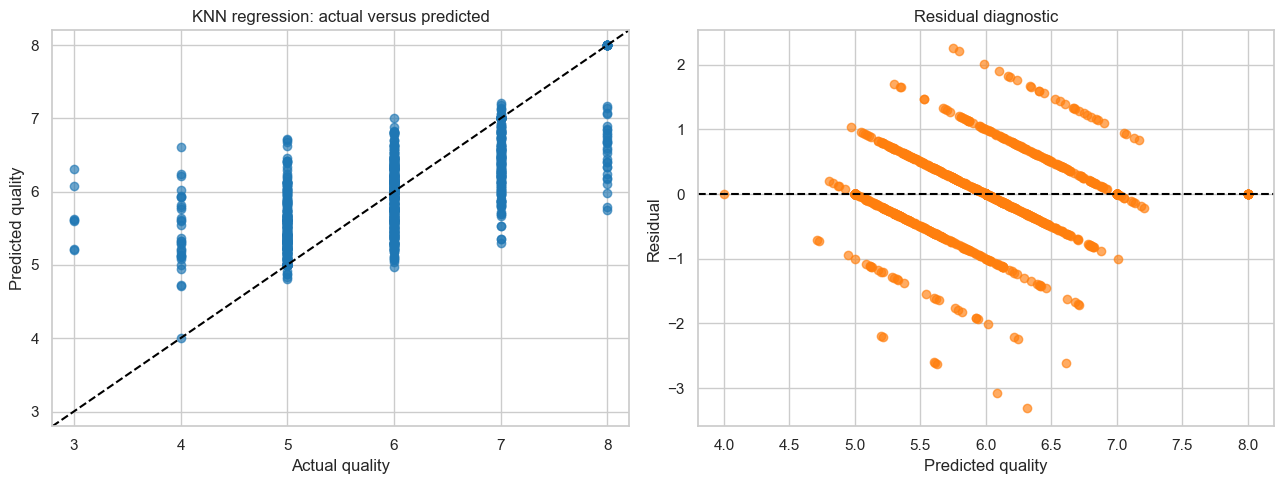

In [7]:
selected_model = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=best_k, weights="distance"))
selected_model.fit(X_train, y_train)
selected_prediction = selected_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, selected_prediction, alpha=0.65, color="tab:blue")
limits = [min(y_test.min(), selected_prediction.min()) - 0.2, max(y_test.max(), selected_prediction.max()) + 0.2]
axes[0].plot(limits, limits, linestyle="--", color="black")
axes[0].set_xlim(limits)
axes[0].set_ylim(limits)
axes[0].set_xlabel("Actual quality")
axes[0].set_ylabel("Predicted quality")
axes[0].set_title("KNN regression: actual versus predicted")
residuals = y_test - selected_prediction
axes[1].scatter(selected_prediction, residuals, alpha=0.65, color="tab:orange")
axes[1].axhline(0, linestyle="--", color="black")
axes[1].set_xlabel("Predicted quality")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residual diagnostic")
plt.tight_layout()
plt.show()

## 4. Select K with RMSE cross-validation

We reserve a test subset and use five-fold cross-validation only on training rows to compare odd K values. RMSE is the square root of average squared error:

$$
\text{RMSE}=\sqrt{\frac{1}{m}\sum_{j=1}^{m}(y_j-\hat{y}_j)^2}.
$$

It penalizes larger errors more strongly than MAE. The curve reports a mean and standard deviation across folds. Do not treat an isolated tiny minimum as decisive when nearby values have similar performance. A stable region is often a better operational choice than the most locally tuned value.

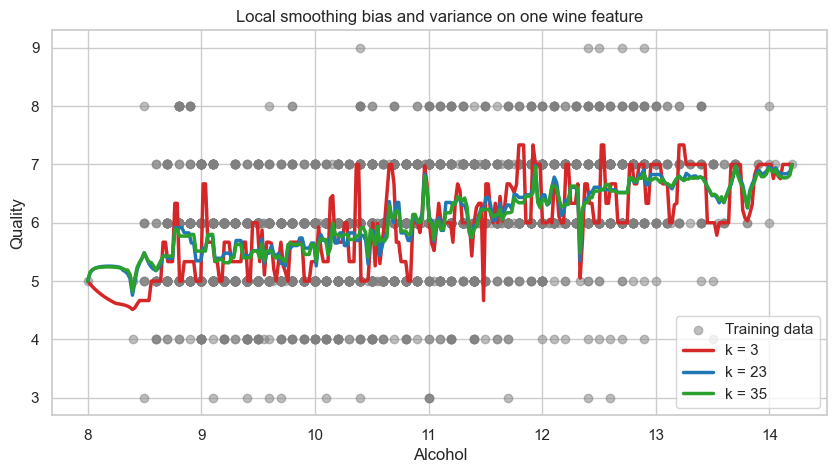

In [8]:
feature = "alcohol"
one_X = wine[[feature]]
one_y = wine["quality"]
one_train, one_test, target_train, target_test = train_test_split(one_X, one_y, test_size=0.25, random_state=RANDOM_STATE)
one_scaler = StandardScaler().fit(one_train)
one_train_scaled = one_scaler.transform(one_train)
one_grid = np.linspace(one_X[feature].min(), one_X[feature].max(), 300).reshape(-1, 1)
one_grid_scaled = one_scaler.transform(pd.DataFrame({feature: one_grid.ravel()}))

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(one_train[feature], target_train, alpha=0.5, color="gray", label="Training data")
for k_value, color in zip([3, best_k, 35], ["tab:red", "tab:blue", "tab:green"]):
    model = KNeighborsRegressor(n_neighbors=k_value, weights="distance").fit(one_train_scaled, target_train)
    ax.plot(one_grid.ravel(), model.predict(one_grid_scaled), color=color, linewidth=2.5, label=f"k = {k_value}")
ax.set_xlabel("Alcohol")
ax.set_ylabel("Quality")
ax.set_title("Local smoothing bias and variance on one wine feature")
ax.legend()
plt.show()

## 5. Weighting, residuals, and calibration limits

After selecting K, we compare uniform and distance weighting on the held-out test set. MAE reports typical absolute error, RMSE emphasizes large mistakes, and $R^2$ compares the prediction variance explained with a constant-mean baseline. None of these metrics proves that predictions are well calibrated for a decision. The quality score is ordinal and human-defined, so an error of one point may not mean the same thing everywhere.

The actual-versus-predicted plot looks for broad agreement, while residuals look for patterns. A systematic residual trend can suggest missing nonlinear structure, insufficient features, changing noise, or poor local density. KNN is a smoother, not a guarantee that every local pattern is represented.

In [9]:
query = X_test.iloc[[0]]
query_scaled = selected_model.named_steps["standardscaler"].transform(query)
distances, indices = selected_model.named_steps["kneighborsregressor"].kneighbors(query_scaled)
neighbors = X_train.iloc[indices[0]].copy()
neighbors["quality"] = y_train.iloc[indices[0]].to_numpy()
neighbors["distance"] = distances[0]

display(query.assign(actual_quality=y_test.iloc[0], predicted_quality=selected_prediction[0]).round(3))
display(neighbors.sort_values("distance").head(12).round(3))

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,actual_quality,predicted_quality
4656,6.0,0.29,0.41,10.8,0.048,55.0,149.0,0.994,3.09,0.59,10.967,7,7.0


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,distance
4654,6.0,0.29,0.41,10.8,0.048,55.0,149.0,0.994,3.09,0.59,10.967,7,0.000
4655,6.0,0.29,0.41,10.8,0.048,55.0,149.0,0.994,3.09,0.59,10.967,7,0.000
4634,5.8,0.29,0.38,10.7,0.038,49.0,136.0,0.994,3.11,0.59,11.200,6,0.787
4784,6.4,0.31,0.31,12.9,0.045,55.0,161.0,0.995,3.02,0.59,10.200,5,1.473
4788,6.4,0.31,0.31,12.9,0.045,55.0,161.0,0.995,3.02,0.59,10.200,5,1.473
3939,6.2,0.27,0.32,6.3,0.048,47.0,159.0,0.993,3.21,0.60,11.000,6,1.563
186,6.7,0.24,0.41,9.4,0.040,49.0,166.0,0.995,3.12,0.61,9.900,6,1.604
3944,6.1,0.27,0.32,6.2,0.048,47.0,161.0,0.993,3.22,0.60,11.000,6,1.604
4144,6.8,0.28,0.29,11.9,0.052,51.0,149.0,0.995,3.02,0.58,10.400,6,1.676
4140,6.8,0.28,0.29,11.9,0.052,51.0,149.0,0.995,3.02,0.58,10.400,6,1.676


## 6. Bias and variance in one interpretable feature

To make smoothing easy to see, we fit one-feature KNN regressors using alcohol only. A very small K can make abrupt changes as alcohol changes; a larger K produces a gentler curve. This does not mean alcohol alone explains quality. It is a visualization of how the same local averaging mechanism changes as K changes.

Bias and variance are not directly observed in a single split. They describe expected behavior across possible datasets. Cross-validation and repeated experiments give evidence about the trade-off, but they do not eliminate uncertainty. Select K with validation, then keep the final test set for an honest estimate.

## 7. Local evidence and limitations

The neighbor table shows which wine rows influence one query prediction. Distance-weighted KNN gives the closest rows the largest contribution. This can be useful for explanation and debugging, but it does not prove causation. Similar chemistry in recorded columns may hide unmeasured production methods, region, storage, or sensory variation.

KNN regression interpolates within observed regions and extrapolates poorly outside them. If a new wine has chemical measurements outside the training range, its nearest examples may still be far away. It also retains training examples and can be expensive for large datasets. Good practice includes scaling, feature selection, validation, distance inspection, and a fallback or uncertainty flag when no close neighbor exists.

## 8. Exercises and summary

1. Repeat the K search with MAE instead of RMSE. Does the selected region change?
2. Compare KNN regression with a linear regression baseline on the same Wine Quality split.
3. Add random noise columns and observe how the K curve changes.
4. Use a radius-neighbors regressor and define what should happen when no neighbor is inside the radius.
5. Group residuals by rounded alcohol level and inspect whether error changes across the feature range.

### Summary

KNN regression predicts continuous targets by smoothing neighboring target values. K controls the local bias-variance balance: small K is flexible and variable; large K is stable and biased. We visualized this effect, selected K with leakage-safe RMSE validation, compared weighting rules, diagnosed predictions with residuals, and inspected local evidence. Reliable KNN regression depends on meaningful distances, adequate local data density, sensible metrics, and honest validation.